**Phase 9 — External validation of the primary GP on out-of-distribution photoswitches**

This notebook scores the manuscript primary Gaussian Process (GP) from notebook `04c` on photoswitch molecules that were **never seen** during training, scaling, or hyperparameter optimisation. The model representation is unchanged: 256-bit binary Morgan fingerprints (radius 2) concatenated with largest conjugated-system size (`LargestConjugatedSystemSize`). The fitted objects are `gp_full_local_model.joblib` and `scaler_gp.joblib`.

**Holdout construction.** The experimental source is Griffiths, Fuchter *et al.* (`photoswitches.csv`, $n$ = 405 rows; *Chem. Sci.* 2022). Stereo-free InChIKey matching to curated Beard et al. (2019) ($n$ = 6,878), removal of rows lacking E-isomer π→π\* $\lambda_{\mathrm{max}}$, and averaging of duplicate structures yields **318** unique OOD molecules in `external_validation.csv`. The GP is **not refit**. `purchasable_switch.csv` (7,265 SMILES) is an unlabeled catalog and is **not** this experimental table.

**What this experiment tests.** Random and scaffold splits (notebooks `04c` and `08`) remain *in-distribution* with respect to the Beard literature corpus. This holdout is chemically narrower (azo photoswitches) and label-cleaner (E π→π\* rather than mixed literature $\lambda_{\mathrm{max}}$), but it is structurally out of distribution relative to the 6,878-compound training universe.

**Software (SI §S6).** Python 3.10.20; RDKit 2025.09.5; scikit-learn 1.7.2; `random_state = 42`. Primary kernel prior: `ConstantKernel × RBF + WhiteKernel` with the bounds reported in SI §S6.2. Fitted hyperparameters on the random-split training set ($n$ = 5,502): $169^{2} \times \mathrm{RBF}(16.9) + \mathrm{White}(5.28 \times 10^{3})$.

**Imports**

In [1]:
import pandas as pd
import numpy as np
import joblib
from rdkit import Chem
from rdkit.Chem import AllChem, DataStructs
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

**Curation audit: Griffiths experimental table ($n$ = 405) → OOD holdout ($n$ = 318)**

`purchasable_switch.csv` in this folder is **7,265 purchasable SMILES with no experimental $\lambda_{\mathrm{max}}$**. It cannot be the 405 → 318 trail. The experimental table is `photoswitches.csv` (Griffiths *Chem. Sci.* 2022): 405 rows, including E-isomer π→π\* wavelengths.

Exclusion is **not** only “drop molecules in Beard.” The funnel is:

1. Stereo-free InChIKey (uncharged, stereo removed) vs `beard_model_ready_features.csv`.
2. Drop rows whose key is already in the 6,878-compound Beard set.
3. Drop OOD rows with missing E π→π\* $\lambda_{\mathrm{max}}$.
4. Collapse remaining duplicate keys (mean $\lambda_{\mathrm{max}}$).

The next cell reproduces that count and checks that the keys match `external_validation.csv`.

In [8]:
from pathlib import Path

from rdkit import RDLogger
from rdkit.Chem.MolStandardize import rdMolStandardize

RDLogger.DisableLog("rdApp.*")
UNCHARGER = rdMolStandardize.Uncharger()


def mol_from_smiles(smi):
    """Parse and sanitize a SMILES string; return None if invalid."""
    if not isinstance(smi, str) or not smi.strip():
        return None
    mol = Chem.MolFromSmiles(smi)
    if mol is None:
        return None
    try:
        Chem.SanitizeMol(mol)
    except Exception:
        return None
    return mol


def inchikey_nostereo(smi):
    """Structure identity ignoring E/Z and tetrahedral stereo, matching the OOD filter."""
    mol = mol_from_smiles(smi)
    if mol is None:
        return None
    try:
        mol = UNCHARGER.uncharge(mol)
        Chem.SanitizeMol(mol)
    except Exception:
        pass
    Chem.RemoveStereochemistry(mol)
    try:
        return Chem.MolToInchiKey(mol)
    except Exception:
        return None


root = Path("..")
purchasable_path = root / "purchasable_switch.csv"
ps_path = Path("photoswitches.csv")
beard_path = Path("beard_model_ready_features.csv")
ext_path = Path("external_validation.csv")

purchasable = pd.read_csv(purchasable_path)
ps = pd.read_csv(ps_path)
beard = pd.read_csv(beard_path)
ext = pd.read_csv(ext_path)

print("=== File identities ===")
print(f"purchasable_switch.csv: {len(purchasable)} rows, columns = {list(purchasable.columns)}")
print(f"photoswitches.csv:      {len(ps)} rows, {ps.shape[1]} columns (experimental table)")
print(f"beard_model_ready_features.csv: {len(beard)} compounds")
print(f"external_validation.csv: {len(ext)} molecules")

label_col = "E isomer pi-pi* wavelength in nm"
beard_keys = set(beard["canonical_smi"].map(inchikey_nostereo).dropna())

ps = ps.copy()
ps["inchikey_nostereo"] = ps["SMILES"].map(inchikey_nostereo)
ps["in_beard"] = ps["inchikey_nostereo"].isin(beard_keys)

n_rows = len(ps)
n_in_beard_rows = int(ps["in_beard"].sum())
n_in_beard_keys = int(ps.loc[ps["in_beard"], "inchikey_nostereo"].nunique())
ood = ps.loc[~ps["in_beard"]].copy()
n_ood_rows = len(ood)
n_ood_missing_label = int(ood[label_col].isna().sum())
labelled = ood.dropna(subset=[label_col, "inchikey_nostereo"])
n_labelled_ood_rows = len(labelled)
n_unique_ood = int(labelled["inchikey_nostereo"].nunique())
n_duplicate_extra = n_labelled_ood_rows - n_unique_ood

print("\n=== Curation funnel (photoswitches.csv) ===")
print(f"1. Experimental rows:                         {n_rows}")
print(f"   unique SMILES / unique stereo-free keys:   {ps['SMILES'].nunique()} / {ps['inchikey_nostereo'].nunique()}")
print(f"2. Rows whose key is already in Beard 6,878:  {n_in_beard_rows}  ({n_in_beard_keys} unique structures)")
print(f"3. Remaining OOD rows:                        {n_ood_rows}")
print(f"4. OOD rows missing E π→π* λmax:              {n_ood_missing_label}")
print(f"5. OOD rows with label:                       {n_labelled_ood_rows}")
print(f"6. Extra duplicate rows then averaged:        {n_duplicate_extra}")
print(f"7. Unique OOD structures (holdout):           {n_unique_ood}")

ext_keys = set(ext["inchikey_nostereo"])
keep_keys = set(labelled["inchikey_nostereo"])
print("\n=== Consistency with external_validation.csv ===")
print(f"inchikey sets identical: {ext_keys == keep_keys}")
print(f"n(external_validation) = {len(ext)} ; n(unique OOD keys) = {n_unique_ood}")


=== File identities ===
purchasable_switch.csv: 7265 rows, columns = ['SMILES']
photoswitches.csv:      405 rows, 34 columns (experimental table)
beard_model_ready_features.csv: 6878 compounds
external_validation.csv: 318 molecules



=== Curation funnel (photoswitches.csv) ===
1. Experimental rows:                         405
   unique SMILES / unique stereo-free keys:   404 / 396
2. Rows whose key is already in Beard 6,878:  66  (65 unique structures)
3. Remaining OOD rows:                        339
4. OOD rows missing E π→π* λmax:              13
5. OOD rows with label:                       326
6. Extra duplicate rows then averaged:        8
7. Unique OOD structures (holdout):           318

=== Consistency with external_validation.csv ===
inchikey sets identical: True
n(external_validation) = 318 ; n(unique OOD keys) = 318


**Load the OOD photoswitch table and inspect the experimental label, missingness, and solvent coverage**

The CSV already stores the ten Beard mechanism descriptors for provenance, but the primary GP uses only `canonical_smi` (to rebuild Morgan bits) and `LargestConjugatedSystemSize`. Solvent is recorded for later diagnosis; it is not a model input. A complete label column is required before any scoring.

In [2]:
df_ext = pd.read_csv("external_validation.csv")

print("=== Holdout table ===")
print(f"n_molecules: {len(df_ext)}")
print(f"columns: {list(df_ext.columns)}")
print("\nMissing values per column:")
print(df_ext.isna().sum())
print("\nlambda_max_exp_nm summary:")
print(df_ext["lambda_max_exp_nm"].describe()[["count", "mean", "std", "min", "max"]])
print("\nirradiation_solvent value counts (including missing):")
print(df_ext["irradiation_solvent"].value_counts(dropna=False))
print("\nLargestConjugatedSystemSize summary:")
print(df_ext["LargestConjugatedSystemSize"].describe()[["mean", "std", "min", "max"]])
print("\nlambda_max_assignment:", df_ext["lambda_max_assignment"].unique().tolist())
print("source:", df_ext["source"].unique().tolist())

=== Holdout table ===
n_molecules: 318
columns: ['SMI', 'canonical_smi', 'lambda_max_exp_nm', 'HeavyAtomCount', 'LargestConjugatedSystemSize', 'TPSA', 'NumHDonors', 'NumRotatableBonds', 'FractionCSP3', 'MolLogP_clipped', 'NumDonorGroups', 'NumAcceptorGroups', 'HasPushPull', 'lambda_max_std_nm', 'n_merged_rows', 'irradiation_solvent', 'inchikey_nostereo', 'lambda_max_assignment', 'source']

Missing values per column:
SMI                              0
canonical_smi                    0
lambda_max_exp_nm                0
HeavyAtomCount                   0
LargestConjugatedSystemSize      0
TPSA                             0
NumHDonors                       0
NumRotatableBonds                0
FractionCSP3                     0
MolLogP_clipped                  0
NumDonorGroups                   0
NumAcceptorGroups                0
HasPushPull                      0
lambda_max_std_nm                0
n_merged_rows                    0
irradiation_solvent            114
inchikey_nostereo   

**Load the primary fingerprint GP and confirm SI §S6 identity — the model is applied, not retrained**

`n_features_in_` must be 257 (256 fingerprint bits + conjugated-system size). The printed `kernel_` string must match the random-split fit reported in the manuscript. `n_restarts_optimizer = 2` and `random_state = 42` are the SI §S6.2 full-fit settings.

In [3]:
gp = joblib.load("gp_full_local_model.joblib")
scaler = joblib.load("scaler_gp.joblib")

print("=== Loaded primary GP ===")
print(f"kernel_: {gp.kernel_}")
print(f"n_features_in_ (GP): {gp.n_features_in_}")
print(f"n_features_in_ (scaler): {scaler.n_features_in_}")
print("Expected: 257 features (256 Morgan bits + LargestConjugatedSystemSize)")
print(f"n_restarts_optimizer: {gp.n_restarts_optimizer}")
print(f"random_state: {gp.random_state}")
print(f"X_train_ shape: {gp.X_train_.shape}")

=== Loaded primary GP ===
kernel_: 169**2 * RBF(length_scale=16.9) + WhiteKernel(noise_level=5.28e+03)
n_features_in_ (GP): 257
n_features_in_ (scaler): 257
Expected: 257 features (256 Morgan bits + LargestConjugatedSystemSize)
n_restarts_optimizer: 2
random_state: 42
X_train_ shape: (5502, 257)


**Recompute the manuscript representation: 256-bit Morgan (radius 2) + largest conjugated-system size**

Fingerprints are generated from `canonical_smi` with the same `AllChem.GetMorganFingerprintAsBitVect` recipe as notebook `04c` (binary bits, radius 2, 256 bits, columns `fp_0`…`fp_255`). RDKit 2025.09.5 emits a `MorganGenerator` deprecation warning; the legacy call is retained so the bit layout matches the saved scaler and GP. `LargestConjugatedSystemSize` is already tabulated and is appended as the 257th column. No other descriptor from the CSV enters the model matrix.

In [4]:
def get_morgan_fp(smi, radius=2, n_bits=256):
    """Binary Morgan fingerprint matching Beard GP notebook 04c.

    Encodes local circular substructure around each atom so that azo
    photoswitches are represented in the same hashed bit space as the
    heterogeneous Beard UV-Vis training corpus.
    """
    mol = Chem.MolFromSmiles(smi)
    if mol is None:
        return None
    fp = AllChem.GetMorganFingerprintAsBitVect(mol, radius=radius, nBits=n_bits)
    arr = np.zeros((n_bits,), dtype=int)
    DataStructs.ConvertToNumpyArray(fp, arr)
    return arr


n_bits = 256
fp_list = df_ext["canonical_smi"].apply(get_morgan_fp)
n_failed = int(fp_list.isna().sum())
print(f"Fingerprint generation failures: {n_failed}")

fp_matrix = np.stack(fp_list.dropna().to_numpy())
fp_df = pd.DataFrame(fp_matrix, columns=[f"fp_{i}" for i in range(n_bits)])

X_ext = pd.concat(
    [
        fp_df.reset_index(drop=True),
        df_ext.loc[fp_list.notna(), ["LargestConjugatedSystemSize"]].reset_index(drop=True),
    ],
    axis=1,
)
y_ext = df_ext.loc[fp_list.notna(), "lambda_max_exp_nm"].reset_index(drop=True)

print(f"X_ext shape: {X_ext.shape}  (expected (318, 257) if no failures)")
print(f"y_ext shape: {y_ext.shape}")
print(f"Average bits on per molecule: {fp_matrix.sum(axis=1).mean():.1f} / {n_bits}")
print(f"First 5 columns: {list(X_ext.columns[:5])}")
print(f"Column order tail: {list(X_ext.columns[-3:])}")

Fingerprint generation failures: 0
X_ext shape: (318, 257)  (expected (318, 257) if no failures)
y_ext shape: (318,)
Average bits on per molecule: 29.8 / 256
First 5 columns: ['fp_0', 'fp_1', 'fp_2', 'fp_3', 'fp_4']
Column order tail: ['fp_254', 'fp_255', 'LargestConjugatedSystemSize']


[19:31:34] DEPRECATION WARNING: please use MorganGenerator
[19:31:34] DEPRECATION WARNING: please use MorganGenerator
[19:31:34] DEPRECATION WARNING: please use MorganGenerator
[19:31:34] DEPRECATION WARNING: please use MorganGenerator
[19:31:34] DEPRECATION WARNING: please use MorganGenerator
[19:31:34] DEPRECATION WARNING: please use MorganGenerator
[19:31:34] DEPRECATION WARNING: please use MorganGenerator
[19:31:34] DEPRECATION WARNING: please use MorganGenerator
[19:31:34] DEPRECATION WARNING: please use MorganGenerator
[19:31:34] DEPRECATION WARNING: please use MorganGenerator
[19:31:34] DEPRECATION WARNING: please use MorganGenerator
[19:31:34] DEPRECATION WARNING: please use MorganGenerator
[19:31:34] DEPRECATION WARNING: please use MorganGenerator
[19:31:34] DEPRECATION WARNING: please use MorganGenerator
[19:31:34] DEPRECATION WARNING: please use MorganGenerator
[19:31:34] DEPRECATION WARNING: please use MorganGenerator
[19:31:34] DEPRECATION WARNING: please use MorganGenerat

**Scale with the training-set scaler and score the holdout (`transform` only)**

The scaler was fitted on the Beard random-split training fold ($n$ = 5,502). Refitting it on the photoswitch table would leak holdout moments into the feature scale and would no longer be the published model. Predictive means and standard deviations are requested together (`return_std=True`). Reported metrics: RMSE, MAE, $R^{2}$, mean residual (prediction − experiment), mean GP standard deviation, and the Pearson correlation between $|\mathrm{error}|$ and predictive std (the same calibration diagnostic used in `04c`).

Reference *in-distribution* numbers (do not expect them to be reproduced here): random-split test RMSE = 92.15 nm, $R^{2}$ = 0.455; scaffold-split test RMSE = 105.93 nm, $R^{2}$ = 0.241.

In [5]:
X_ext_scaled = scaler.transform(X_ext)  # transform only; do not refit
y_pred, y_std = gp.predict(X_ext_scaled, return_std=True)

y_true = y_ext.to_numpy()
rmse = float(np.sqrt(mean_squared_error(y_true, y_pred)))
mae = float(mean_absolute_error(y_true, y_pred))
r2 = float(r2_score(y_true, y_pred))
calib_r = float(np.corrcoef(y_std, np.abs(y_true - y_pred))[0, 1])
mean_residual = float((y_pred - y_true).mean())

print(f"n = {len(y_true)}")
print(f"RMSE = {rmse:.2f} nm")
print(f"MAE  = {mae:.2f} nm")
print(f"R²   = {r2:.3f}")
print(f"mean GP std = {y_std.mean():.2f} nm")
print(f"std of GP std = {y_std.std():.2f} nm")
print(f"calibration r (|error| vs std) = {calib_r:.3f}")
print(f"mean residual (pred - exp) = {mean_residual:.2f} nm")
print("\nReference (Beard random test split): RMSE = 92.15 nm, R² = 0.455")
print("Reference (Beard scaffold test split): RMSE = 105.93 nm, R² = 0.241")

n = 318
RMSE = 77.02 nm
MAE  = 64.79 nm
R²   = -0.269
mean GP std = 100.63 nm
std of GP std = 12.52 nm
calibration r (|error| vs std) = -0.019
mean residual (pred - exp) = 53.45 nm

Reference (Beard random test split): RMSE = 92.15 nm, R² = 0.455
Reference (Beard scaffold test split): RMSE = 105.93 nm, R² = 0.241


**How to read the numbers — negative $R^{2}$ is not a collapsed GP**

sklearn $R^{2}$ asks whether predictions beat *this holdout's own mean* (385 nm). The holdout RMSE (77 nm) exceeds that null RMSE (68 nm), so $R^{2}$ is negative. That is not the degenerate descriptor-GP failure of notebook `04`. The kernel is the published $169^{2}\times\mathrm{RBF}(16.9)+\mathrm{White}(5.28\times 10^{3})$ fit; every molecule receives a distinct prediction.

The error budget is dominated by a **systematic $+53$ nm red shift** (GP mean 439 nm vs experimental mean 385 nm). Pearson $r = 0.61$ and bias-corrected $R^{2} \approx 0.34$ show that ranking inside the azo class survived. The offset is chemically plausible: Beard labels are mixed literature $\lambda_{\mathrm{max}}$, whereas this table is E-isomer $\pi\rightarrow\pi^{\ast}$ only.

The next cell plots predicted vs experimental $\lambda_{\mathrm{max}}$ so the offset and the remaining trend can be seen together.

**Predicted vs experimental $\lambda_{\mathrm{max}}$ on the OOD photoswitch holdout**

Points are coloured by `LargestConjugatedSystemSize`. The red dashed line is $y=x$. The black dotted line is the same identity shifted by the observed mean residual ($+53$ nm). A collapsed model would sit on a horizontal band; a purely biased but still ranking model follows the dotted line.

In [ ]:
import matplotlib.pyplot as plt

y_true = y_ext.to_numpy()
conj = X_ext["LargestConjugatedSystemSize"].to_numpy()
pearson = float(np.corrcoef(y_true, y_pred)[0, 1])

lo = float(min(y_true.min(), y_pred.min()) - 20)
hi = float(max(y_true.max(), y_pred.max()) + 20)

plt.figure(figsize=(8, 8))
sc = plt.scatter(
    y_true,
    y_pred,
    c=conj,
    cmap="viridis",
    alpha=0.7,
    s=28,
    edgecolors="none",
)
plt.plot([lo, hi], [lo, hi], "r--", linewidth=1, label="Perfect prediction")
plt.plot(
    [lo, hi],
    [lo + mean_residual, hi + mean_residual],
    "k:",
    linewidth=1.2,
    label=f"Identity + mean bias ({mean_residual:.1f} nm)",
)
plt.xlabel("Experimental λmax (nm)")
plt.ylabel("Predicted λmax (nm)")
plt.title("OOD photoswitches: GP predicted vs experimental λmax\n(E-isomer π→π*, n = 318)")
plt.colorbar(sc, label="Largest conjugated-system size")
plt.xlim(lo, hi)
plt.ylim(lo, hi)
plt.legend(loc="upper left")
plt.tight_layout()
plt.savefig("predicted_vs_true_lambda_max_OOD.png", dpi=300)
plt.show()

print(f"Pearson r = {pearson:.3f}")
print(f"Mean residual (pred − exp) = {mean_residual:.2f} nm")
print(f"RMSE = {rmse:.2f} nm;  R² = {r2:.3f}")
print("Saved: predicted_vs_true_lambda_max_OOD.png")


**Residual vs largest conjugated-system size**

Residual is experimental minus predicted $\lambda_{\mathrm{max}}$, matching notebook `07`. A collapsed model would be unstructured noise around zero. If the $+53$ nm bias were a conjugation-length failure (the GP missing extra delocalisation in azo dyes), the residual would trend with `LargestConjugatedSystemSize`. A flat band below zero means a **global red shift**, not a conjugation-specific collapse.

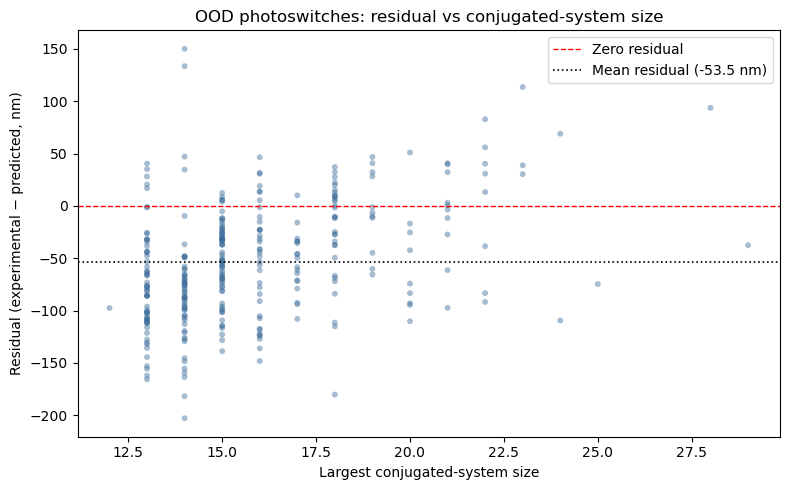

Correlation (conjugation size vs signed residual): 0.413
Mean residual (exp − pred) = -53.45 nm
Saved: residual_vs_conjugation_OOD.png


In [7]:
residual = y_true - y_pred  # experimental − predicted, as in notebook 07
conj = X_ext["LargestConjugatedSystemSize"].to_numpy()

plt.figure(figsize=(8, 5))
plt.scatter(conj, residual, alpha=0.45, s=18, c="#3b6b9a", edgecolors="none")
plt.axhline(0, color="red", linestyle="--", linewidth=1, label="Zero residual")
plt.axhline(residual.mean(), color="black", linestyle=":", linewidth=1.2,
            label=f"Mean residual ({residual.mean():.1f} nm)")
plt.xlabel("Largest conjugated-system size")
plt.ylabel("Residual (experimental − predicted, nm)")
plt.title("OOD photoswitches: residual vs conjugated-system size")
plt.legend(loc="upper right")
plt.tight_layout()
plt.savefig("residual_vs_conjugation_OOD.png", dpi=300)
plt.show()

corr_resid_conj = float(np.corrcoef(conj, residual)[0, 1])
print(f"Correlation (conjugation size vs signed residual): {corr_resid_conj:.3f}")
print(f"Mean residual (exp − pred) = {residual.mean():.2f} nm")
print("Saved: residual_vs_conjugation_OOD.png")
